Import Libraries

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

Load Dataset

In [ ]:
df = pd.read_csv("/content/Mall_Customers.csv")

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


Check Dataset Information

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [ ]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [ ]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


Select Features

In [ ]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


Scale the Data

In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[-1.73899919, -0.43480148],
       [-1.73899919,  1.19570407],
       [-1.70082976, -1.71591298],
       [-1.70082976,  1.04041783],
       [-1.66266033, -0.39597992]])

Find the Best Number of Clusters (Elbow Method)

In [ ]:
wcss = []

for i in range(1,11):
    model = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)

    wcss.append(model.inertia_)

Plot the Elbow Graph

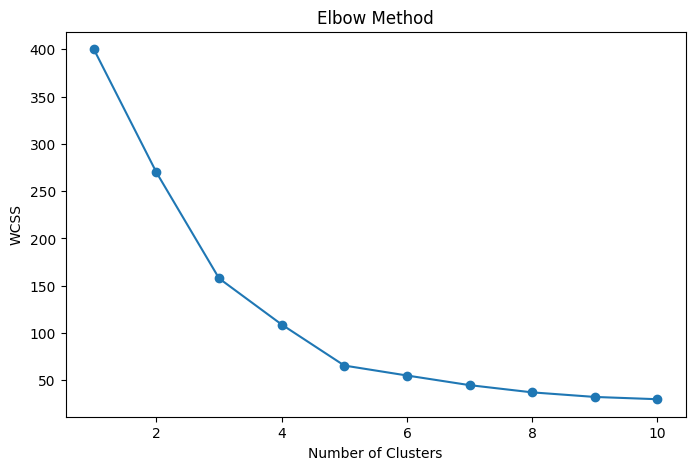

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.show()

Silhouette Score

In [ ]:
scores = []

for i in range(2,11):

    model = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)

    scores.append(score)

Plot Silhouette Scores

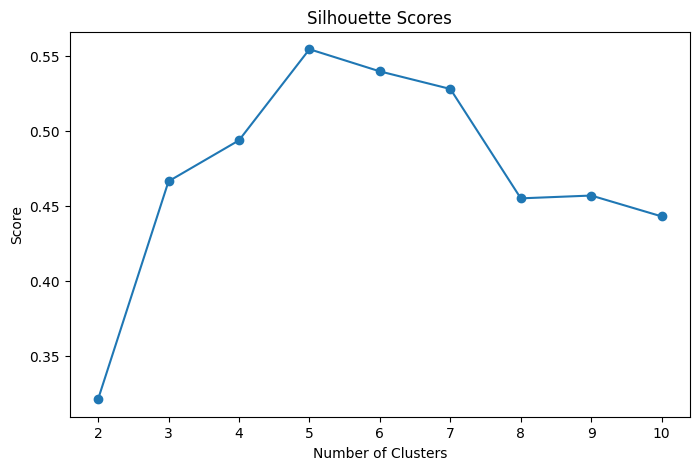

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(range(2,11), scores, marker='o')

plt.title("Silhouette Scores")
plt.xlabel("Number of Clusters")
plt.ylabel("Score")

plt.show()

Train Final Model

In [ ]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

Add Cluster Labels

In [ ]:
df['Cluster'] = clusters

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


Display Centroids

In [ ]:
centroids = scaler.inverse_transform(kmeans.cluster_centers_)

centroids

array([[55.2962963 , 49.51851852],
       [86.53846154, 82.12820513],
       [25.72727273, 79.36363636],
       [88.2       , 17.11428571],
       [26.30434783, 20.91304348]])

Convert Centroids to Table

In [ ]:
centroid_df = pd.DataFrame(
    centroids,
    columns=[
        'Annual Income',
        'Spending Score'
    ]
)

centroid_df

,Annual Income,Spending Score
0,55.296296,49.518519
1,86.538462,82.128205
2,25.727273,79.363636
3,88.200000,17.114286
4,26.304348,20.913043


Final Cluster Visualization

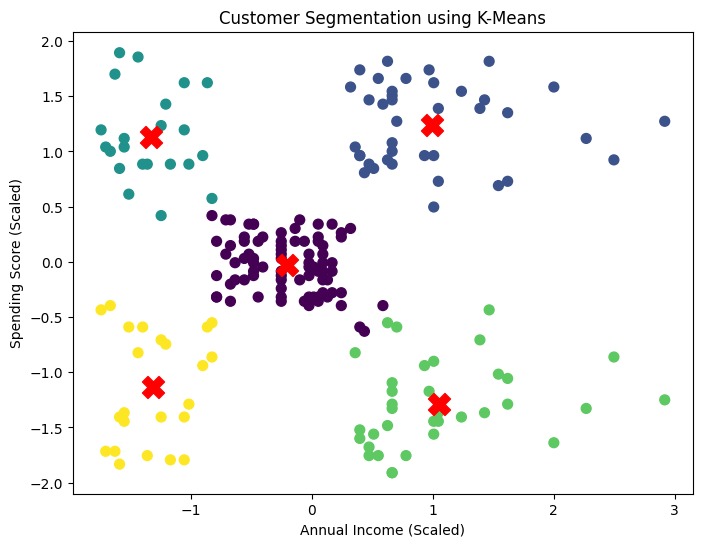

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_scaled[:,0],
    X_scaled[:,1],
    c=clusters,
    cmap='viridis',
    s=50
)

plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    color='red',
    marker='X',
    s=250
)

plt.title("Customer Segmentation using K-Means")
plt.xlabel("Annual Income (Scaled)")
plt.ylabel("Spending Score (Scaled)")

plt.show()

K-Means clustering successfully grouped the customers into five distinct segments based on Annual Income and Spending Score. The Elbow Method and Silhouette Score were used to determine the optimal number of clusters. These customer segments help businesses understand customer behavior and develop targeted marketing strategies to improve customer satisfaction and increase sales.